In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

[[15]]
(array([[[1322., 1648.],
        [1349., 1629.],
        [1366., 1648.],
        [1339., 1666.]]], dtype=float32),)
1344 1648


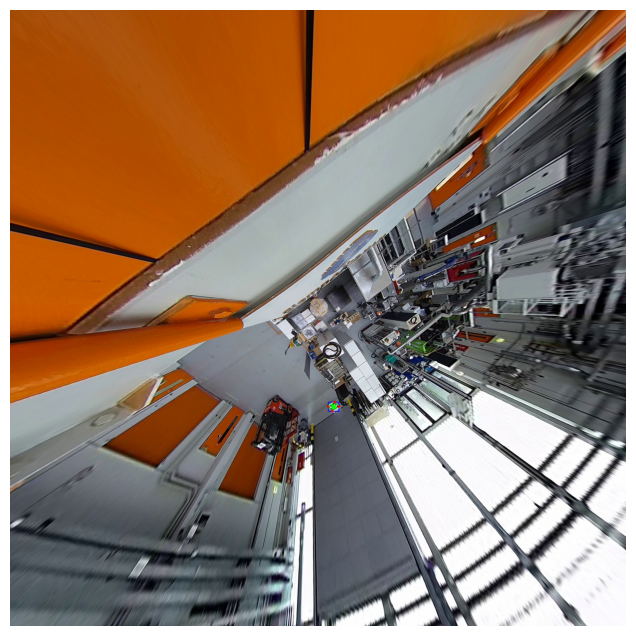

In [12]:
img = cv2.imread("fisheye_15/fisheye_233_fov.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, params)

corners, ids, _ = detector.detectMarkers(gray)

vis = img.copy()

if ids is not None:
    for c, marker_id in zip(corners, ids.flatten()):
        pts = c[0].astype(int)
        cv2.polylines(vis, [pts], True, (0,255,0), 2)
        x, y, w, h = cv2.boundingRect(pts)
        x1, y1 = x, y
        x2, y2 = x + w, y + h
        cx = int((x1 + x2) /2) 
        cy = int((y1 + y2) /2)
        cv2.rectangle(vis, (x1,y1), (x2,y2), (255,0,0), 2)
        for (px, py) in pts:
            cv2.circle(vis, (px, py), 5, (0,0,255), -1)
        print(ids)
        print(corners)
        print(cx,cy)
        cv2.circle(vis, (cx, cy), 10, (0,255,0), -1)

else:
    print("No ArUco marker detected")


plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


[[15]]
(array([[[1229., 1525.],
        [1260., 1503.],
        [1281., 1528.],
        [1251., 1549.]]], dtype=float32),)
1255 1526


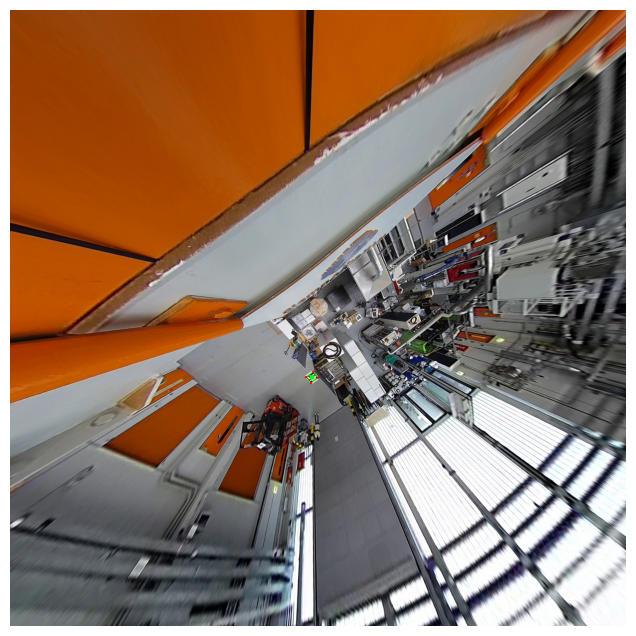

[[15]]
(array([[[1180., 1439.],
        [1213., 1414.],
        [1238., 1442.],
        [1206., 1466.]]], dtype=float32),)
1209 1440


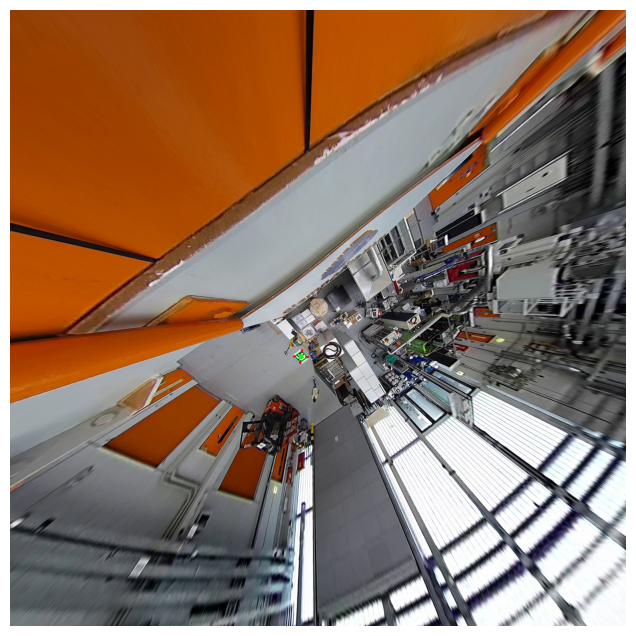

[[15]]
(array([[[1071., 1387.],
        [1107., 1360.],
        [1139., 1391.],
        [1104., 1418.]]], dtype=float32),)
1105 1389


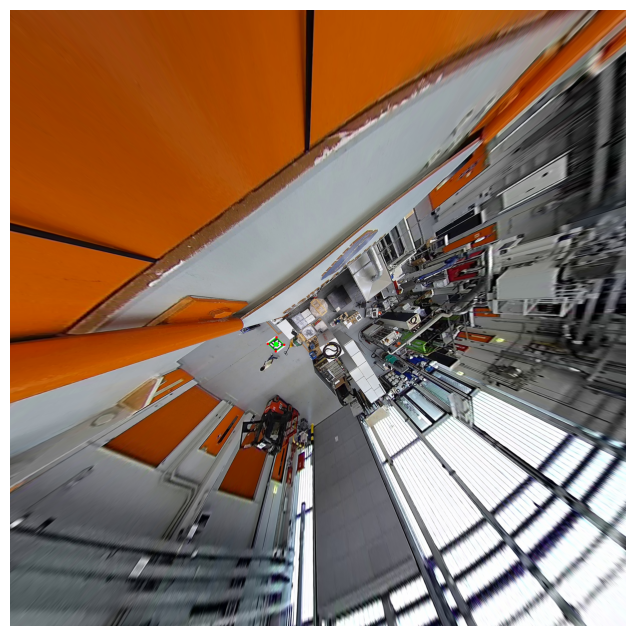

[[15]]
(array([[[ 894., 1386.],
        [ 933., 1357.],
        [ 974., 1390.],
        [ 937., 1419.]]], dtype=float32),)
934 1388


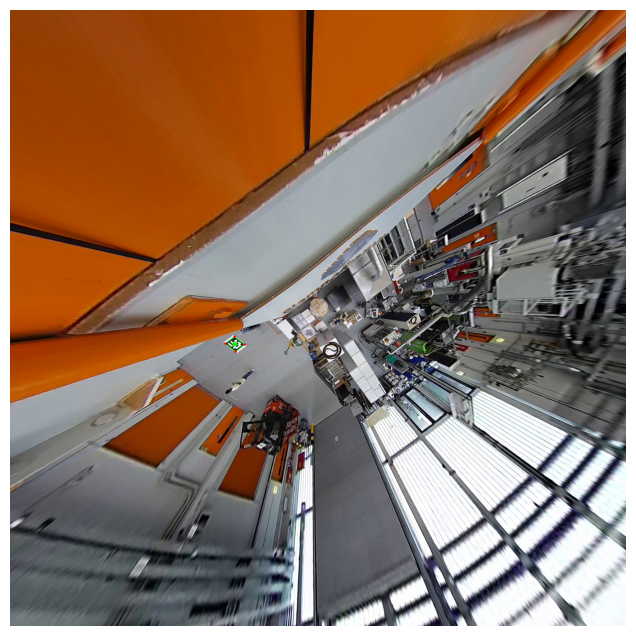

[[15]]
(array([[[ 825., 1546.],
        [ 862., 1522.],
        [ 901., 1549.],
        [ 865., 1573.]]], dtype=float32),)
863 1548


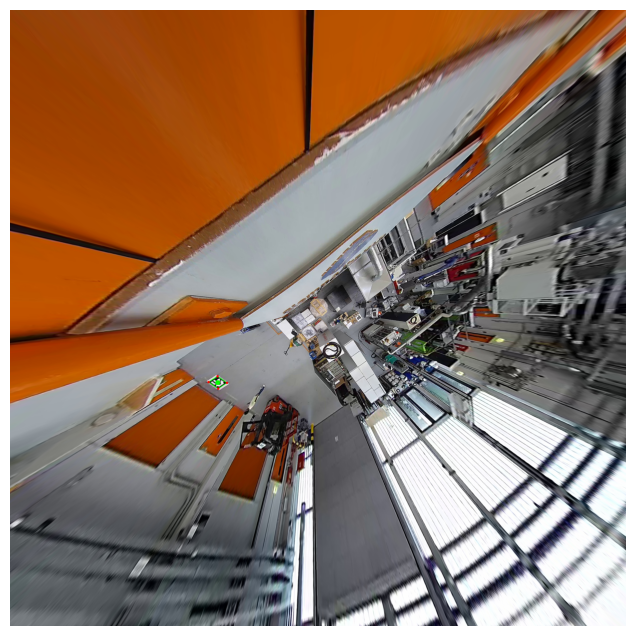

[[15]]
(array([[[ 857., 1521.],
        [ 893., 1497.],
        [ 932., 1525.],
        [ 896., 1549.]]], dtype=float32),)
895 1523


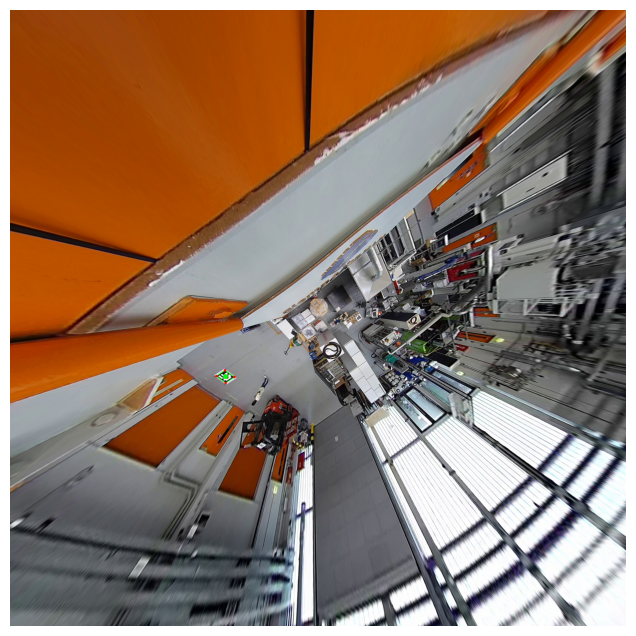

[[15]]
(array([[[ 981., 1604.],
        [1016., 1582.],
        [1045., 1606.],
        [1011., 1627.]]], dtype=float32),)
1013 1605


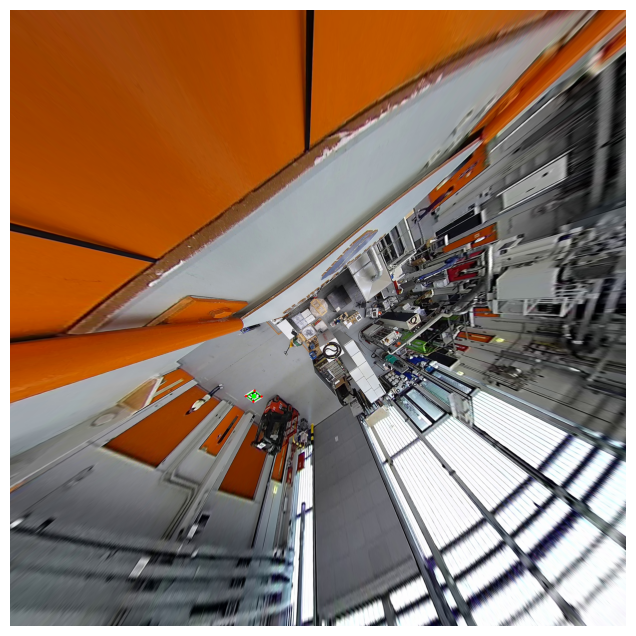

[[15]]
(array([[[1169., 1596.],
        [1199., 1574.],
        [1222., 1597.],
        [1193., 1618.]]], dtype=float32),)
1196 1596


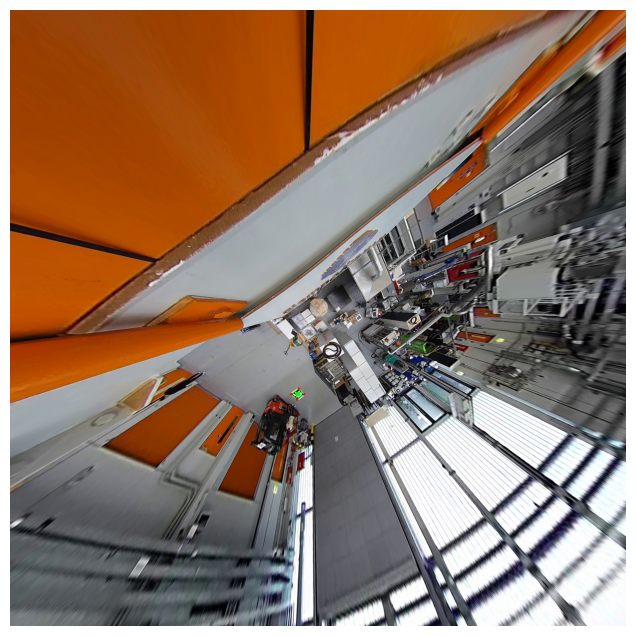

[[15]]
(array([[[1360., 1653.],
        [1334., 1672.],
        [1316., 1654.],
        [1343., 1635.]]], dtype=float32),)
1338 1654


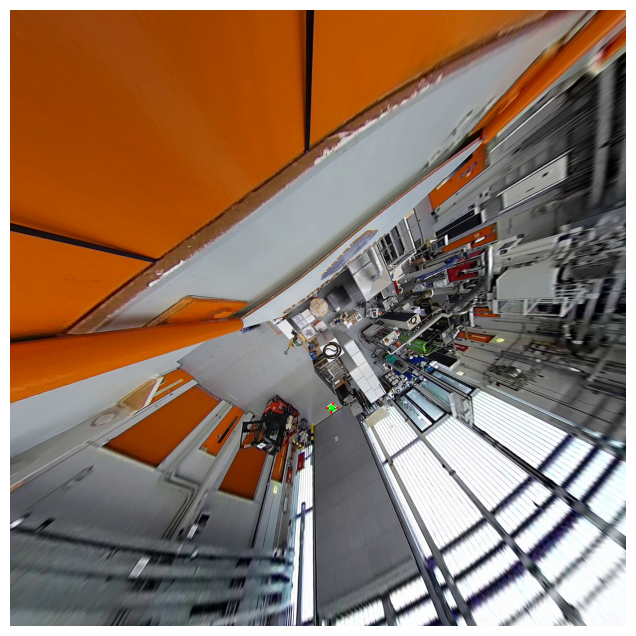

In [ ]:
fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708
}
image_dir = "capture_15"
point_233 = []
for filename in sorted(os.listdir(image_dir)):
    if not filename.lower().endswith("233.jpg"):
        continue

    img_path = os.path.join(image_dir, filename)
    img = cv2.imread(img_path)
    Hf, Wf = fisheye_params["height"], fisheye_params["width"]
    cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
    radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]

    i = 160
    rect_w, rect_h = 2560, 2560
    fov = i
    fov_RAD = np.deg2rad(fov)
    focal = (rect_w / 2) / np.tan(fov_RAD / 2)

    K_rect = np.array([[focal, 0.0, rect_w / 2],
                    [0.0, focal, rect_h / 2],
                    [0.0, 0.0, 1.0]])

    f_fish = radius / theta_max
    K_fish = np.array([[f_fish, 0.0, cx_f],
                    [0.0, f_fish, cy_f],
                    [0.0, 0.0, 1.0]])
    D_fish = np.zeros((4, 1)) 


    balance = 1.0
    dim_rect = (rect_w, rect_h)
    rectilinear = cv2.fisheye.undistortImage(img, K_fish, D_fish, Knew=K_rect, new_size=dim_rect)
    gray = cv2.cvtColor(rectilinear, cv2.COLOR_BGR2GRAY)

    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
    params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, params)

    corners, ids, _ = detector.detectMarkers(gray)
    vis = rectilinear.copy()

    if ids is not None:
        for c, marker_id in zip(corners, ids.flatten()):
            pts = c[0].astype(int)
            cv2.polylines(vis, [pts], True, (0,255,0), 2)
            x, y, w, h = cv2.boundingRect(pts)
            x1, y1 = x, y
            x2, y2 = x + w, y + h
            cx = int((x1 + x2) /2) 
            cy = int((y1 + y2) /2)
            point_233.append((cx,cy))
            for (px, py) in pts:
                cv2.circle(vis, (px, py), 5, (0,0,255), -1)
            print(ids)
            print(corners)
            print(cx,cy)
            cv2.circle(vis, (cx, cy), 10, (0,255,0), -1)

    else:
        print("No ArUco marker detected")


    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [ ]:
point_229

[(1466, 1818),
 (1572, 1669),
 (1584, 1496),
 (1502, 1313),
 (1256, 1309),
 (1305, 1331),
 (1218, 1519),
 (1312, 1790),
 (1271, 2118)]

In [27]:
point_233

[(1255, 1526),
 (1209, 1440),
 (1105, 1389),
 (934, 1388),
 (863, 1548),
 (895, 1523),
 (1013, 1605),
 (1196, 1596),
 (1338, 1654)]

In [ ]:
src_points = np.array(point_229, dtype=np.float32)
dst_points = np.array(point_233, dtype=np.float32)

print("Source", src_points)
print("Destination:", dst_points)

h, mask = cv2.findHomography(src_points, dst_points, cv2.RANSAC)
print("\nHomography Matrix:\n", h)

Source [[1466. 1818.]
 [1572. 1669.]
 [1584. 1496.]
 [1502. 1313.]
 [1256. 1309.]
 [1305. 1331.]
 [1218. 1519.]
 [1312. 1790.]
 [1271. 2118.]]
Destination: [[1255. 1526.]
 [1209. 1440.]
 [1105. 1389.]
 [ 934. 1388.]
 [ 863. 1548.]
 [ 895. 1523.]
 [1013. 1605.]
 [1196. 1596.]
 [1338. 1654.]]

Homography Matrix:
 [[-2.72846454e-02  2.48169455e+00 -1.69120288e+03]
 [-1.92877115e+00  2.07173090e+00  2.44308064e+03]
 [-5.52840999e-04  1.11449403e-03  1.00000000e+00]]


In [41]:
np.save("Homography_229_to_233.npy", h)

In [42]:
H_229_to_233 = np.load("Homography_229_to_233.npy")
H_233_to_BEV = np.load("Homography for 233_camera_.npy")

In [50]:
H_229_to_BEV = H_233_to_BEV @ H_229_to_233
print(H_229_to_BEV)

[[-2.55072731e-01  4.27600688e-01  9.33592438e+02]
 [-3.15749082e-01  1.76245146e-02  1.01175356e+03]
 [-1.34683809e-04  2.07894324e-04  7.92250725e-01]]


In [44]:
np.save("Homography_229_to_233_to_BEV.npy", H_229_to_BEV)

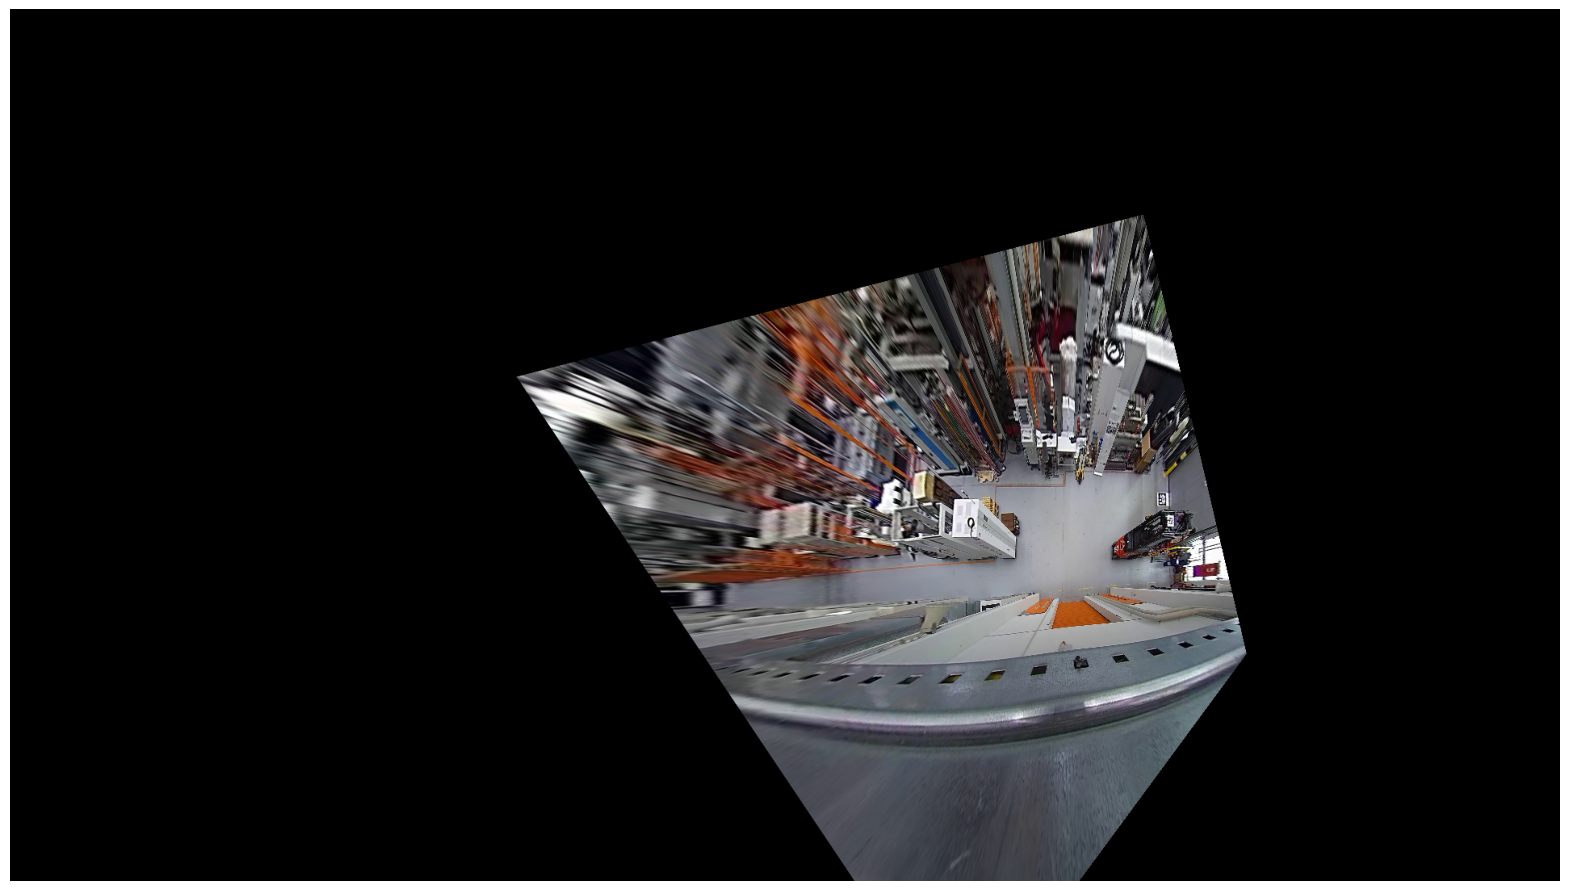

In [51]:
img_src = cv2.imread("fisheye_15/fisheye_229_fov.jpg")
wraped = cv2.warpPerspective(img_src, H_229_to_BEV,(1920,1080))
wraped_rgb = cv2.cvtColor(wraped, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20,12))
plt.imshow(wraped_rgb)
plt.axis("off")
plt.show()